# SINDy-SHRED: FitzHugh-Nagumo Example

Demonstrates the full SINDy-SHRED workflow on a synthetic dataset generated from the FitzHugh-Nagumo model with spatially delayed copies.

**What this notebook covers:**
1. Generate synthetic spatio-temporal data
2. Train a SINDy-SHRED model from sparse sensor measurements
3. Discover interpretable governing equations in the latent space
4. Evaluate reconstruction and forecast performance

For the Sea Surface Temperature application see `sea_surface_temperature.ipynb`.

## 1. Setup

In [2]:
import copy
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from scipy.integrate import solve_ivp

from sindy_shred import SINDySHRED, plotting

warnings.filterwarnings("ignore")

RESULTS_DIR = "results/fitzhugh_nagumo"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: results/fitzhugh_nagumo


In [3]:
# Device selection
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed(SEED)

Using device: cuda


In [4]:
sns.set_context("paper")
sns.set_style("whitegrid")

pcolor_kwargs = {"vmin": -3, "vmax": 3, "cmap": "RdBu_r", "rasterized": True}

## 2. Data Generation

The [FitzHugh-Nagumo model](https://en.wikipedia.org/wiki/FitzHugh%E2%80%93Nagumo_model) is a 2D excitable system:

$$\dot{v} = v - \tfrac{1}{3}v^3 - w + I_{\text{ext}}$$
$$\dot{w} = \tfrac{1}{\tau}(v + a - b\,w)$$

We generate a 20-dimensional dataset by creating 10 spatially delayed copies of the solution $(v, w)$.

In [5]:
def rhs_FNM(t, x, tau, a, b, Iext):
    v, w = x
    vdot = v - (v**3) / 3 - w + Iext
    wdot = (1 / tau) * (v + a - b * w)
    return np.array([vdot, wdot])

In [6]:
# Solve the ODE
T, dt_solve = 64, 0.0001 * 8
t_solution = np.arange(0, T, dt_solve)
x0 = np.array([-1.110, -0.125])
solution_fn = solve_ivp(rhs_FNM, [0, T], x0, t_eval=t_solution,
                        args=(2, 0.7, 0.8, 0.65))

# Spatially delayed copies
num_space_dims = 10
delays = np.linspace(0, 2, num_space_dims)
uv_spatial = np.zeros((len(t_solution), 2 * num_space_dims))
for i in range(num_space_dims):
    delay_steps = int(delays[i] / dt_solve)
    if delay_steps == 0:
        uv_spatial[:, 2*i : 2*i+2] = solution_fn.y.T
    else:
        uv_spatial[:, 2*i : 2*i+2] = np.vstack(
            [np.tile(x0, (delay_steps, 1)), solution_fn.y.T[:-delay_steps, :]]
        )

# Subsample
substep = 50
uv_spatial = uv_spatial[::substep]
t_solution = t_solution[::substep]
dt_data = t_solution[1] - t_solution[0]

data_original = uv_spatial.T          # (space, time)
n_space_dims = data_original.shape[0]
print(f"Data shape (space x time): {data_original.shape}")

Data shape (space x time): (20, 1600)


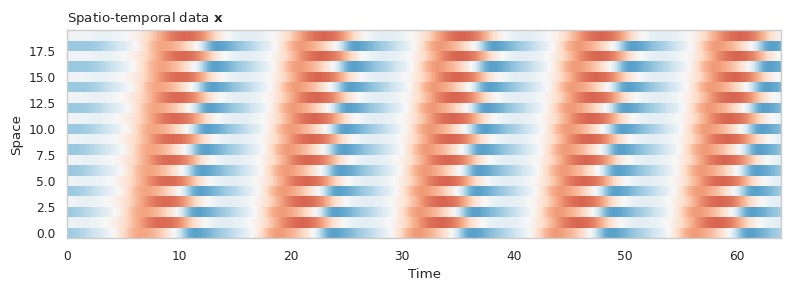

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.pcolormesh(t_solution, np.arange(n_space_dims), data_original, **pcolor_kwargs)
ax.set_title(r"Spatio-temporal data $\mathbf{x}$", loc="left")
ax.set_ylabel("Space")
ax.set_xlabel("Time")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/data_original.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 3. Model Setup

Subsample the data, pick sensor locations, and set model hyperparameters.

In [8]:
# Subsample by 4 to reduce sequence length
load_X = copy.deepcopy(data_original).T[::4]   # (time, space)
dt = dt_data * 4
time = t_solution[::4]

n_time, n_space = load_X.shape

# Sensor and model configuration
sensor_locations = np.array([5, 14, 7])
num_sensors      = len(sensor_locations)
latent_dim       = 2
poly_order       = 3
lags             = 120 // 4    # trajectory window fed to the GRU
train_length     = 750 // 4

print(f"Data:          {load_X.shape}  (time x space)")
print(f"Sensors:       {sensor_locations}  ({num_sensors} total)")
print(f"Latent dim:    {latent_dim}")
print(f"Poly order:    {poly_order}")
print(f"Lags (window): {lags}")
print(f"Train length:  {train_length}")

Data:          (400, 20)  (time x space)
Sensors:       [ 5 14  7]  (3 total)
Latent dim:    2
Poly order:    3
Lags (window): 30
Train length:  187


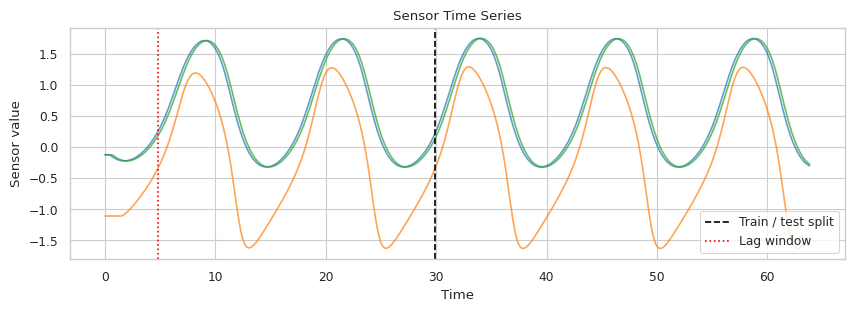

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time, load_X[:, sensor_locations], alpha=0.7)
ax.axvline(time[train_length], color="k", linestyle="--", label="Train / test split")
ax.axvline(time[lags],         color="r", linestyle=":",  label="Lag window")
ax.set_xlabel("Time")
ax.set_ylabel("Sensor value")
ax.set_title("Sensor Time Series")
ax.legend()
plt.show()

## 4. Train SINDy-SHRED

`SINDySHRED` handles data splitting, min-max scaling, GRU + decoder training, and the SINDy regularization term in a single `fit()` call.

In [10]:
model = SINDySHRED(
    latent_dim=latent_dim,
    poly_order=poly_order,
    ode_order=1,              # 1st-order ODE: z' = f(z)
    num_epochs=600,
    sindy_regularization=10.0,
    threshold=0.05,           # sparsity threshold, applied every thres_epoch epochs
    thres_epoch=100,
    lr=1e-3,
    verbose=True,
    device=device,
)

model.fit(
    num_sensors=num_sensors,
    dt=dt,
    x_to_fit=load_X,
    lags=lags,
    train_length=train_length,
    validate_length=0,
    sensor_locations=sensor_locations,
)

1 : tensor(0.3208, device='cuda:0', grad_fn=<AddBackward0>)
2 : tensor(0.2153, device='cuda:0', grad_fn=<AddBackward0>)
3 : tensor(0.2461, device='cuda:0', grad_fn=<AddBackward0>)
4 : tensor(0.2441, device='cuda:0', grad_fn=<AddBackward0>)
5 : tensor(0.2183, device='cuda:0', grad_fn=<AddBackward0>)
6 : tensor(0.2047, device='cuda:0', grad_fn=<AddBackward0>)
7 : tensor(0.2041, device='cuda:0', grad_fn=<AddBackward0>)
8 : tensor(0.2048, device='cuda:0', grad_fn=<AddBackward0>)
9 : tensor(0.1979, device='cuda:0', grad_fn=<AddBackward0>)
10 : tensor(0.1997, device='cuda:0', grad_fn=<AddBackward0>)
11 : tensor(0.2016, device='cuda:0', grad_fn=<AddBackward0>)
12 : tensor(0.2064, device='cuda:0', grad_fn=<AddBackward0>)
13 : tensor(0.2063, device='cuda:0', grad_fn=<AddBackward0>)
14 : tensor(0.2004, device='cuda:0', grad_fn=<AddBackward0>)
15 : tensor(0.1931, device='cuda:0', grad_fn=<AddBackward0>)
16 : tensor(0.1932, device='cuda:0', grad_fn=<AddBackward0>)
17 : tensor(0.1909, device='cuda:

## 5. SINDy Equation Discovery

After training, post-hoc SINDy identifies sparse governing equations in the latent space by differentiating the GRU trajectories and regressing against a polynomial library.

SINDy-derived dynamical equation (1st order):

(x0)' =  0.730 x0 + -0.650 x1 +  0.121 x0 x1 + -0.160 x1^2 + -0.611 x0^3 +  0.428 x0^2 x1 + -0.201 x1^3
(x1)' =  0.486 x0 + -0.427 x1 + -0.122 x0^2 +  0.115 x0 x1 +  0.132 x0^3 +  0.120 x1^3


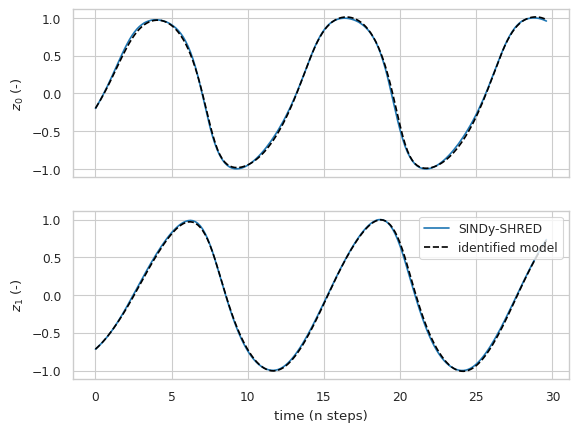

In [11]:
model.sindy_identify(
    threshold=0.05,
    plot_result=True,
    save_path=f"{RESULTS_DIR}/latent_comparison",
)

### True Governing Equations (for reference)

$$\dot{v} = v - \tfrac{1}{3}v^3 - w + 0.65, \qquad
  \dot{w} = \tfrac{1}{2}(v + 0.7 - 0.8\,w)$$

SINDy-SHRED operates on a *normalized latent space*, so the discovered coefficients will differ numerically from the true parameters above — but the **active terms** (polynomial monomials with non-zero coefficients) should match the structure of the true equations.

---

**Alternative — automatic threshold selection:**  
Call `model.auto_tune_threshold()` instead of (or after) `sindy_identify` to automatically find the sparsest stable model.

In [12]:
# Uncomment to automatically select the best sparsity threshold
# best_threshold, tune_results = model.auto_tune_threshold(
#     adaptive=True,          # nonparametric: derive range from least-squares solution
#     scale_factor=0.2,       # max_threshold = scale_factor * max(|coefficients|)
#     n_thresholds=10,
#     metric="sparsity_stable",   # pick sparsest stable model
#     verbose=True,
# )
# print(f"Best threshold: {best_threshold:.4f}")

## 6. Evaluate Reconstruction

Test relative reconstruction error: 0.0467


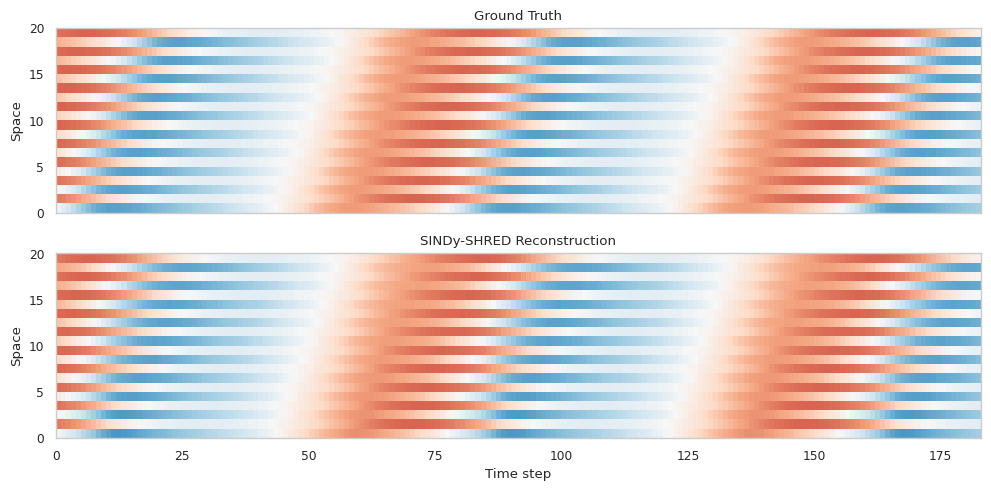

In [13]:
test_recons      = model.sensor_recon(data_type="test", return_scaled=False)
test_ground_truth = model._scaler.inverse_transform(
    model._test_data.Y.detach().cpu().numpy()
)

err = model.relative_error(test_recons, test_ground_truth)
print(f"Test relative reconstruction error: {err:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].pcolormesh(test_ground_truth.T, **pcolor_kwargs)
axes[0].set_title("Ground Truth")
axes[0].set_ylabel("Space")
axes[1].pcolormesh(test_recons.T, **pcolor_kwargs)
axes[1].set_title("SINDy-SHRED Reconstruction")
axes[1].set_ylabel("Space")
axes[1].set_xlabel("Time step")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/reconstruction_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

## 7. Forecast

Integrate the discovered SINDy model forward from the last training point, then decode the latent trajectory back to physical space with the shallow decoder.

SINDy latent prediction: (183, 2)
Decoded physical space:  (183, 20)


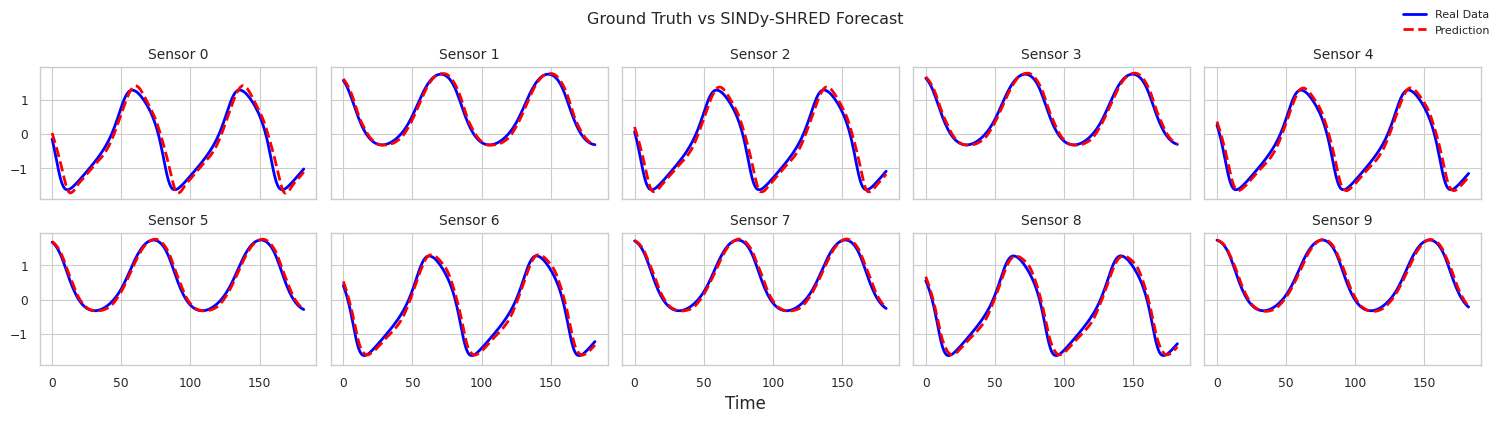

In [16]:
# forecast() = sindy_predict() from the last training point + shred_decode() + inverse-scale
sindy_physical = model.forecast(return_scaled=False)
x_predict      = model.predict_latent(split="train", init_from="last")

print(f"SINDy latent prediction: {x_predict.shape}")
print(f"Decoded physical space:  {sindy_physical.shape}")

fig, axes = plotting.plot_sensor_predictions(
    test_ground_truth,
    sindy_physical[:len(test_ground_truth)],
    sensor_locations=np.arange(n_space_dims),
    rows=2, cols=5,
    save_path=f"{RESULTS_DIR}/sensor_predictions_grid.pdf",
)
fig.suptitle("Ground Truth vs SINDy-SHRED Forecast")
fig.tight_layout()
plt.show()

## 8. Customization & Advanced Usage

### Key parameters

| Parameter | What it controls |
|-----------|-----------------|
| `latent_dim` | GRU hidden size — also the dimensionality of the discovered ODE |
| `poly_order` | Polynomial order of the SINDy library (higher = more candidate terms) |
| `ode_order` | `1` for $z'=f(z)$, `2` for $z''=f(z,z')$ (adds velocity to state) |
| `sindy_regularization` | Weight of the SINDy consistency loss; `0` reduces to plain SHRED |
| `threshold` | Coefficient magnitude below which terms are zeroed (sparsification) |
| `thres_epoch` | Sparsification is applied every this many epochs |
| `include_sine` | Add $\sin(\cdot)$ terms to the SINDy library |
| `num_epochs`, `lr` | Standard training hyperparameters |

### Direct network access

For full control over the network architecture or training loop, the underlying `SINDy_SHRED_net` and `fit()` function are importable directly:

```python
from sindy_shred import sindy, sindy_shred_net
from sindy_shred.utils import TimeSeriesDataset

# Access the trained network from a fitted SINDySHRED model
net = model._shred   # SINDy_SHRED_net instance

# Or build a custom network from scratch
custom_net = sindy_shred_net.SINDy_SHRED_net(
    input_size=num_sensors,
    output_size=n_space,
    hidden_size=4,           # custom latent dim
    hidden_layers=3,         # deeper GRU
    l1=256, l2=512,          # custom decoder widths
    library_dim=sindy.library_size(latent_dim, poly_order),
    poly_order=poly_order,
    dt=dt,
)
sindy_shred_net.fit(custom_net, train_dataset, valid_dataset,
                    num_epochs=1000, lr=5e-4, sindy_regularization=5.0)
```

## 9. Save Results

In [15]:
import json, sys
from io import StringIO

# Latent trajectories
gru_train = model.gru_normalize(data_type="train").detach().cpu().numpy()
gru_test  = model.gru_normalize(data_type="test").detach().cpu().numpy()
np.save(f"{RESULTS_DIR}/latent_train.npy", gru_train)
np.save(f"{RESULTS_DIR}/latent_test.npy",  gru_test)
np.save(f"{RESULTS_DIR}/latent_sindy_predict.npy", x_predict)
print(f"Saved latent trajectories")

# SINDy model
sindy_coeff = model._model.coefficients()
np.save(f"{RESULTS_DIR}/sindy_coefficients.npy", sindy_coeff)
with open(f"{RESULTS_DIR}/sindy_feature_names.txt", "w") as f:
    f.write("\n".join(model._model.get_feature_names()))

_buf = StringIO()
_old, sys.stdout = sys.stdout, _buf
model._model.print()
sys.stdout = _old
with open(f"{RESULTS_DIR}/sindy_equations.txt", "w") as f:
    f.write(_buf.getvalue())

# Config + metrics
json.dump({
    "latent_dim": latent_dim, "poly_order": poly_order,
    "num_sensors": num_sensors, "lags": lags,
    "train_length": train_length, "dt": dt,
}, open(f"{RESULTS_DIR}/config.json", "w"), indent=2)

json.dump({
    "reconstruction_error": float(err),
}, open(f"{RESULTS_DIR}/results.json", "w"), indent=2)

print(f"All results saved to {RESULTS_DIR}/")

Saved latent trajectories
All results saved to results/fitzhugh_nagumo/
